# Import Statements

In [1]:
import pickle
import numpy as np
import pandas as pd
import scipy
import sklearn
import shap
import xgboost as xgb
import seaborn as sns
import matplotlib.pyplot as plt
import tqdm as notebook_tqdm
import skopt
import copy

/home/supadhyaya/.local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from statistics import mean
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import mean_squared_error
from scipy.stats import pearsonr
from scipy import stats
from math import sqrt
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import Lasso
from skopt import BayesSearchCV
from skopt.space import Real, Categorical, Integer
from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.linear_model import Ridge

In [3]:
print(np.__version__)

1.26.3


# Define functions

In [4]:
#set the parameter space for XGBoost regression
space ={'learning_rate': Real(0.01, 1.0, 'log-uniform'),
        'min_child_weight': Integer(0, 10),
        'max_depth': Integer(0, 50),
        'max_delta_step': Integer(0, 20),
        'subsample': Real(0.01, 1.0, 'uniform'),
        'colsample_bytree': Real(0.01, 1.0, 'uniform'),
        'colsample_bylevel': Real(0.01, 1.0, 'uniform'),
        'reg_lambda': Real(1e-9, 1000, 'log-uniform'),
        'reg_alpha': Real(1e-9, 1.0, 'log-uniform'),
        'gamma': Real(1e-9, 0.5, 'log-uniform'),
        'n_estimators': Integer(50, 200),
        }

rr_space = {
    "alpha": Real(1e-5, 1e2, prior="log-uniform")
}

lasso_space = {
    'alpha': Real(1e-5, 1.0, 'log-uniform')  # L1 penalty term
}

In [5]:
#callback function to be used later which stops parameter search if it goes above 98% to save time
def on_step(optim_result):
    """
    Callback meant to view scores after
    each iteration while performing Bayesian
    Optimization in Skopt"""
    score = xgb_bayes_search.best_result_['score']
    print("best score: %s" % score)
    if score >= 0.98:
        print('Interrupting!')
        return True

In [6]:
#input training sets to find the best hyperparameters using Bayesian cross-validation for XGBoost model

def bayesian_xgb_search(X, y,space):
    """
    Perform Bayesian hyperparameter tuning for XGBoost using BayesSearchCV.

    Parameters:
        X_train (array-like): Training feature set.
        y_train (array-like): Training target variable.
        space (dict): Hyperparameter search space.

    Returns:
        xgb.XGBRegressor: Best XGBoost model with tuned parameters.
    """
    xgbreg = xgb.XGBRegressor(n_jobs=1)
    xgb_bayes_search = BayesSearchCV(
        xgbreg, space, n_iter=50, scoring=None, n_jobs=-1,
        cv=5, verbose=1, random_state=42, n_points=12
    )

    xgb_bayes_search.fit(X, y)
    
    print("Best XGB Parameters:", xgb_bayes_search.best_params_)
    
    best_params = xgb_bayes_search.best_params_
    best_xgbreg = xgb.XGBRegressor(**best_params)

    return best_xgbreg

#TO RUN - best_xgbreg = bayesian_xgb_search(X_train, y_train, space) 

def bayesian_lasso_search(X, y, lasso_space):
    lasso = Lasso(max_iter=100000)
    lasso_bayes_search = BayesSearchCV(
        estimator=lasso,
        search_spaces=lasso_space,
        scoring=None,
        cv=5,
        n_iter=10,  # number of iterations to try
        random_state=42,
        verbose=1,
        n_jobs=-1
)
    lasso_bayes_search.fit(X, y)
    
    print("Best Lasso hyperparameters:", lasso_bayes_search.best_params_)
    
    best_params = lasso_bayes_search.best_params_
    best_lasso = Lasso(**best_params)

    return best_lasso



In [7]:
#input full sets except houldout to find the best model using k-fold (10) cross validation which uses the best hyperparametres from the previous step. 

def eval_k_fold(m, X, y, k):
    """
    Evaluates model using k-fold CV and returns the final model trained on full dataset.
    
    Parameters:
    m: model (e.g., XGBoost or RandomForest) with best hyperparameters
    X: feature matrix
    y: labels
    k: number of folds
    """
    cv = KFold(n_splits=k, shuffle=True)
    rmse_results = []
    percent_rmse_results = []
    r2_results = []
 
    low = 100
    best_fold_model = None
    
    for fold, (train, test) in enumerate(cv.split(X, y), start=1):
        print(f"\n=== Fold {fold} ===")
        
        m.fit(X[train], y[train].ravel())
        preds = m.predict(X[test])
        
        ss = sqrt(mean_squared_error(y[test], preds))  
        rr = r2_score(y[test], preds)                  
        mm = np.mean(y[test])
        error_mean = (ss / mm) * 100
        
        rmse_results.append(ss)
        percent_rmse_results.append(error_mean)
        r2_results.append(rr)
        
        print(f"R²: {rr:.4f}, RMSE: {ss:.4f}, %RMSE: {error_mean:.2f}")
        
        if error_mean < low:
            low = error_mean
            best_fold_model = copy.deepcopy(m)
    
    print("\nCV Summary:")
    print(f"Mean %RMSE: {np.mean(percent_rmse_results):.2f} ± {np.std(percent_rmse_results):.2f}")
    
    # Plot %RMSE per fold
    plt.figure(figsize=(8,5), dpi=300)
    cb_palette = ["#E69F00", "#56B4E9", "#009E73"]
    plt.plot(range(1, k+1), percent_rmse_results, marker="o", label="%RMSE", color=cb_palette[0])
    plt.plot(range(1, k+1), rmse_results, marker="s", label="RMSE", color=cb_palette[1])
    plt.plot(range(1, k+1), r2_results, marker="^", label="R²", color=cb_palette[2])
    plt.xlabel("Fold Number")
    plt.ylabel("Metric Value")
    plt.title("Cross-Validation Metrics per Fold")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()
    
    # Retrain the best model on full dataset
    final_model = copy.deepcopy(best_fold_model)
    final_model.fit(X, y.ravel())
    
    metrics = {
        "RMSE": rmse_results,
        "%RMSE": percent_rmse_results,
        "R2": r2_results
    }
    
    return final_model, metrics

#TO RUN - best_model_xgb, results = eval_k_fold(model, X, y, 10)

In [8]:
def plot_xgb_feature_importance(best_model, X_train, top_n=20):
    """
    Computes and plots the feature importance of an XGBoost model based on Gain.

    Parameters:
        best_model (XGBRegressor): Trained XGBoost model from Kfold cross validation.
        X_train (DataFrame): Training feature set used for Kfold CV.
        top_n (int): Number of top features to display. Default is 20.

    Returns:
        DataFrame: DataFrame containing feature importance scores.
    """
    # Generate feature names
    f_names = ['f' + str(i) for i in range(len(X_train.columns))]
    my_dict = best_model.get_booster().get_score(importance_type="gain")

    # Map feature names back to original column names
    new_dict = {X_train.columns[f_names.index(key)]: value for key, value in my_dict.items()}

    # Convert to DataFrame
    df = pd.DataFrame.from_dict(new_dict, orient='index', columns=['F_Score(GAIN)'])

    # Select top N important features
    top_features = df.nlargest(top_n, "F_Score(GAIN)")

    # Plot feature importance
    plt.figure(figsize=(8, 8), dpi=100)
    indexes = top_features.index[::-1]
    values = top_features.values.ravel()[::-1]

    plt.barh(indexes, values)
    plt.title(f'XGBoost Feature Importance for Top {top_n} SNPs')
    plt.ylabel('SNP Label')
    plt.xlabel('Relative F_Score (GAIN)')
    plt.show()
    
    return df

#TO RUN - feature_importance= plot_xgb_feature_importance(best_model, X_train, top_n=20)

In [9]:
def evaluate_holdout_performance(best_model, X_holdout, y_holdout):
    """
    Evaluates the performance of a models on a holdout dataset.

    Parameters:
        best_model (XGBRegressor or RFR): Trained XGBoost/RF model from Kfold CV.
        X_holdout (DataFrame): Holdout feature set.
        y_holdout (Series or array): Holdout target values.

    Returns:
        dict: Dictionary containing RMSE, R2, and mean error percentage.
    """
    # Generate predictions
    all_preds = best_model.predict(X_holdout)

    # Compute performance metrics (correct argument order)
    ss = sqrt(mean_squared_error(y_holdout, all_preds))
    rr = r2_score(y_holdout, all_preds)
    mm = np.mean(y_holdout)
    error_mean = (ss / mm) * 100
    
    # Print evaluation metrics
    print(f"R^2 Value of Holdout: {rr:.2f}")
    print(f"RMSE of Holdout: {ss:.2f}")
    print(f"Mean of Holdout: {mm:.2f}")
    print(f"This is {error_mean:.2f}% of the mean pheno data")
    
    # Prepare data for residual plot
    y_holdout = y_holdout.ravel()
    
    # Debug print first 5 examples
    for i in range(5):
        print(i, y_holdout[i], all_preds[i])
    
    # Create DataFrame for plotting (no artificial filters)
    thisplot = pd.DataFrame({
        'actual': y_holdout,
        'predicted': all_preds
    })
    
    # Generate regression plot
    plt.figure(figsize=(8, 6), dpi=300)
    sns.regplot(x="actual", y="predicted", data=thisplot, scatter_kws={'alpha': 0.5})
    plt.title('XGBoost Predicted vs Actual')
    plt.show()
    
    return {"RMSE": ss, "R2": rr, "Mean Error %": error_mean}

#TO RUN - metrics = evaluate_holdout_performance(best_model, X_holdout, y_holdout)

In [10]:
def plot_residuals(actual, predicted):
    """
    Plots residuals (Predicted - Actual) as a scatter plot.
    
    Parameters:
        actual (array-like): Array of actual values.
        predicted (array-like): Array of predicted values.
    """
    # Convert to NumPy arrays
    actual = np.array(actual)
    predicted = np.array(predicted)
    
    # Compute residuals (Predicted - Actual)
    residuals = predicted - actual
    
    # Create a scatter plot
    plt.figure(figsize=(8, 6))
    sns.scatterplot(x=actual, y=residuals, alpha=0.6)
    
    # Add a horizontal line at y=0 for reference
    plt.axhline(y=0, color='red', linestyle='--')
    
    # Labels and title
    plt.xlabel("Actual Values")
    plt.ylabel("Residuals")
    plt.title("Residual Plot")
    
    # Show the plot
    plt.show()

#TO RUN - Plot_residuals(plot_x, plot_y)

In [11]:
class MultiInputStackingRegressor(BaseEstimator, RegressorMixin):
    def __init__(
        self,
        base_models,
        meta_model=None,
        n_folds=10,
        random_state=42
    ):
        """
        base_models: list of regressors (tuned XGBoost models)
        meta_model: Ridge regression
        """
        self.base_models = base_models
        self.meta_model = meta_model or Ridge(alpha=1.0)
        self.n_folds = n_folds
        self.random_state = random_state

    def fit(self, X_list, y):
        """
        X_list: [X1, X2, X3]
        y: target array
        """
        self.base_models_ = [list() for _ in self.base_models]
        self.meta_features_ = np.zeros((len(y), len(self.base_models)))

        cv = KFold(
            n_splits=self.n_folds,
            shuffle=True,
            random_state=self.random_state
        )

        for i, model in enumerate(self.base_models):
            for train_idx, val_idx in cv.split(y):
                X_train = X_list[i][train_idx]
                X_val = X_list[i][val_idx]

                model_clone = model.__class__(**model.get_params())
                model_clone.fit(X_train, y[train_idx])
                preds = model_clone.predict(X_val)

                self.meta_features_[val_idx, i] = preds
                self.base_models_[i].append(model_clone)

        self.meta_model.fit(self.meta_features_, y)
        return self

    def predict(self, X_list):
        """
        X_list: [X1, X2, X3]
        """
        meta_features = np.column_stack([
            np.mean(
                [model.predict(X_list[i]) for model in self.base_models_[i]],
                axis=0
            )
            for i in range(len(self.base_models_))
        ])

        return self.meta_model.predict(meta_features)

#The base models are fitted on k-1 folds and make predictions on the remaining fold, that way there's no leakage.
#because the meta model takes predictions of the base model as its input so if the predictions are overfitted then no use. 
#therefore, cv is used iteratevely so there's predictions of every data point (hence the model_clone)

# Run Lasso model

## Load datasets

In [12]:
gene_pav = pd.read_pickle("gene_pav_LASSO_training_data.pkl")

In [13]:
gene_pav.head()

,GlymaLee.02G163600.1.v1.1,GlymaLee.03G021800.1.v1.1,GlymaLee.03G036400.1.v1.1,GlymaLee.05G083000.1.v1.1,GlymaLee.07G051800.1.v1.1,GlymaLee.07G090500.1.v1.1,GlymaLee.08G248800.1.v1.1,GlymaLee.08G248900.1.v1.1,GlymaLee.09G124600.1.v1.1,GlymaLee.10G105000.1.v1.1,...,SOYBEAN.EVALUATION.MS2000_02,SOYBEAN.EVALUATION.MS2001_02,SOYBEAN.EVALUATION.MS2001_03,SOYBEAN.EVALUATION.MS923,SOYBEAN.EVALUATION.MS945,SOYBEAN.EVALUATION.MS967,SOYBEAN.EVALUATION.MS989,SOYBEAN.GENERAL,WILD.SOYBEAN.EVAL.1IL85,seed_oil
new_line,,,,,,,,,,,,,,,,,,,,,
AB-01_SOYBEAN.EVALUATION.4IL87,1,0,1,1,0,0,0,0,1,1,...,0,0,0,0,0,0,0,0,0,17.6
AB-02_SOYBEAN.EVALUATION.MS2001_02,1,1,1,0,1,1,1,1,1,1,...,0,1,0,0,0,0,0,0,0,16.8
BR-24_SOYBEAN.CHEMICAL.NB.2009,1,1,1,1,1,1,0,1,1,1,...,0,0,0,0,0,0,0,0,0,20.6
ESS_SOYBEAN.CHEMICAL.NB.2009,1,1,1,0,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,20.9
ESS_SOYBEAN.EVALUATION.5IL90,1,1,1,0,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,19.6


In [14]:
gene_pav['Data-storage-ID'] = gene_pav.index.to_series().str.split('_').str[0]
#fs_data['Line'] = fs_data.index.str.split('_').str[0]
gene_pav = gene_pav.reset_index(drop=True).set_index('Data-storage-ID')
gene_pav.head()

,GlymaLee.02G163600.1.v1.1,GlymaLee.03G021800.1.v1.1,GlymaLee.03G036400.1.v1.1,GlymaLee.05G083000.1.v1.1,GlymaLee.07G051800.1.v1.1,GlymaLee.07G090500.1.v1.1,GlymaLee.08G248800.1.v1.1,GlymaLee.08G248900.1.v1.1,GlymaLee.09G124600.1.v1.1,GlymaLee.10G105000.1.v1.1,...,SOYBEAN.EVALUATION.MS2000_02,SOYBEAN.EVALUATION.MS2001_02,SOYBEAN.EVALUATION.MS2001_03,SOYBEAN.EVALUATION.MS923,SOYBEAN.EVALUATION.MS945,SOYBEAN.EVALUATION.MS967,SOYBEAN.EVALUATION.MS989,SOYBEAN.GENERAL,WILD.SOYBEAN.EVAL.1IL85,seed_oil
Data-storage-ID,,,,,,,,,,,,,,,,,,,,,
AB-01,1,0,1,1,0,0,0,0,1,1,...,0,0,0,0,0,0,0,0,0,17.6
AB-02,1,1,1,0,1,1,1,1,1,1,...,0,1,0,0,0,0,0,0,0,16.8
BR-24,1,1,1,1,1,1,0,1,1,1,...,0,0,0,0,0,0,0,0,0,20.6
ESS,1,1,1,0,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,20.9
ESS,1,1,1,0,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,19.6


In [15]:
gene_pav.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1144 entries, AB-01 to USB-807
Columns: 188 entries, GlymaLee.02G163600.1.v1.1 to seed_oil
dtypes: float64(1), int64(33), object(154)
memory usage: 1.6+ MB


In [16]:
pav1 = gene_pav.iloc[:, 0:187]
pav1.head()

,GlymaLee.02G163600.1.v1.1,GlymaLee.03G021800.1.v1.1,GlymaLee.03G036400.1.v1.1,GlymaLee.05G083000.1.v1.1,GlymaLee.07G051800.1.v1.1,GlymaLee.07G090500.1.v1.1,GlymaLee.08G248800.1.v1.1,GlymaLee.08G248900.1.v1.1,GlymaLee.09G124600.1.v1.1,GlymaLee.10G105000.1.v1.1,...,SOYBEAN.EVALUATION.MS1999_01,SOYBEAN.EVALUATION.MS2000_02,SOYBEAN.EVALUATION.MS2001_02,SOYBEAN.EVALUATION.MS2001_03,SOYBEAN.EVALUATION.MS923,SOYBEAN.EVALUATION.MS945,SOYBEAN.EVALUATION.MS967,SOYBEAN.EVALUATION.MS989,SOYBEAN.GENERAL,WILD.SOYBEAN.EVAL.1IL85
Data-storage-ID,,,,,,,,,,,,,,,,,,,,,
AB-01,1,0,1,1,0,0,0,0,1,1,...,0,0,0,0,0,0,0,0,0,0
AB-02,1,1,1,0,1,1,1,1,1,1,...,0,0,1,0,0,0,0,0,0,0
BR-24,1,1,1,1,1,1,0,1,1,1,...,0,0,0,0,0,0,0,0,0,0
ESS,1,1,1,0,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
ESS,1,1,1,0,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0


In [17]:
y2 = gene_pav["seed_oil"]
y2.head()

Data-storage-ID
AB-01    17.6
AB-02    16.8
BR-24    20.6
ESS      20.9
ESS      19.6
Name: seed_oil, dtype: float64

In [18]:
snp = pd.read_pickle("lasso_SNP_training_data.pkl")

In [19]:
#snp = pd.read_pickle("../genotypeSNP_yield_holdout_data.pkl")

In [20]:
snp['Data-storage-ID'] = snp.index.to_series().str.split('_').str[0]
#fs_data['Line'] = fs_data.index.str.split('_').str[0]
snp = snp.reset_index(drop=True).set_index('Data-storage-ID')
snp.head()

,Gm01_782148,Gm01_1381480,Gm01_2611788,Gm01_4432828,Gm01_7137165,Gm01_7544276,Gm01_8931835,Gm01_34025243,Gm01_46985479,Gm01_47028050,...,SOYBEAN.EVALUATION.MS2000_02,SOYBEAN.EVALUATION.MS2001_02,SOYBEAN.EVALUATION.MS2001_03,SOYBEAN.EVALUATION.MS923,SOYBEAN.EVALUATION.MS945,SOYBEAN.EVALUATION.MS967,SOYBEAN.EVALUATION.MS989,SOYBEAN.GENERAL,WILD.SOYBEAN.EVAL.1IL85,seed_oil
Data-storage-ID,,,,,,,,,,,,,,,,,,,,,
AB-01,0,0,0,0,0,0,0,2,0,0,...,0,0,0,0,0,0,0,0,0,17.6
AB-02,2,0,0,0,2,2,2,0,0,0,...,0,1,0,0,0,0,0,0,0,16.8
BR-24,0,2,0,0,0,0,0,2,2,2,...,0,0,0,0,0,0,0,0,0,20.6
ESS,0,2,0,0,0,0,0,2,2,2,...,0,0,0,0,0,0,0,0,0,20.9
ESS,0,2,0,0,0,0,0,2,2,2,...,0,0,0,0,0,0,0,0,0,19.6


In [21]:
snp.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1144 entries, AB-01 to USB-807
Columns: 278 entries, Gm01_782148 to seed_oil
dtypes: float64(1), int64(277)
memory usage: 2.4+ MB


In [22]:
snp1 = snp.iloc[:, 0:277]
snp1.head()

,Gm01_782148,Gm01_1381480,Gm01_2611788,Gm01_4432828,Gm01_7137165,Gm01_7544276,Gm01_8931835,Gm01_34025243,Gm01_46985479,Gm01_47028050,...,SOYBEAN.EVALUATION.MS1999_01,SOYBEAN.EVALUATION.MS2000_02,SOYBEAN.EVALUATION.MS2001_02,SOYBEAN.EVALUATION.MS2001_03,SOYBEAN.EVALUATION.MS923,SOYBEAN.EVALUATION.MS945,SOYBEAN.EVALUATION.MS967,SOYBEAN.EVALUATION.MS989,SOYBEAN.GENERAL,WILD.SOYBEAN.EVAL.1IL85
Data-storage-ID,,,,,,,,,,,,,,,,,,,,,
AB-01,0,0,0,0,0,0,0,2,0,0,...,0,0,0,0,0,0,0,0,0,0
AB-02,2,0,0,0,2,2,2,0,0,0,...,0,0,1,0,0,0,0,0,0,0
BR-24,0,2,0,0,0,0,0,2,2,2,...,0,0,0,0,0,0,0,0,0,0
ESS,0,2,0,0,0,0,0,2,2,2,...,0,0,0,0,0,0,0,0,0,0
ESS,0,2,0,0,0,0,0,2,2,2,...,0,0,0,0,0,0,0,0,0,0


In [23]:
y1 = snp["seed_oil"]
y1.head()

Data-storage-ID
AB-01    17.6
AB-02    16.8
BR-24    20.6
ESS      20.9
ESS      19.6
Name: seed_oil, dtype: float64

In [24]:
cov = snp.iloc[:,-34:]
cov.head()

,SOJA.EVALUATION.IL989,SOJA.EVALUATION.MS989,SOYBEAN.CHEMICAL.NB.2009,SOYBEAN.EVALUATION.1IL64,SOYBEAN.EVALUATION.1IL66,SOYBEAN.EVALUATION.1MN63,SOYBEAN.EVALUATION.2IL81.1,SOYBEAN.EVALUATION.2IL81.2,SOYBEAN.EVALUATION.2KY81,SOYBEAN.EVALUATION.2MN81,...,SOYBEAN.EVALUATION.MS2000_02,SOYBEAN.EVALUATION.MS2001_02,SOYBEAN.EVALUATION.MS2001_03,SOYBEAN.EVALUATION.MS923,SOYBEAN.EVALUATION.MS945,SOYBEAN.EVALUATION.MS967,SOYBEAN.EVALUATION.MS989,SOYBEAN.GENERAL,WILD.SOYBEAN.EVAL.1IL85,seed_oil
Data-storage-ID,,,,,,,,,,,,,,,,,,,,,
AB-01,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,17.6
AB-02,0,0,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,16.8
BR-24,0,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,20.6
ESS,0,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,20.9
ESS,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,19.6


In [25]:
cov = cov.drop(columns=['seed_oil'])
cov.head()

,SOJA.EVALUATION.IL989,SOJA.EVALUATION.MS989,SOYBEAN.CHEMICAL.NB.2009,SOYBEAN.EVALUATION.1IL64,SOYBEAN.EVALUATION.1IL66,SOYBEAN.EVALUATION.1MN63,SOYBEAN.EVALUATION.2IL81.1,SOYBEAN.EVALUATION.2IL81.2,SOYBEAN.EVALUATION.2KY81,SOYBEAN.EVALUATION.2MN81,...,SOYBEAN.EVALUATION.MS1999_01,SOYBEAN.EVALUATION.MS2000_02,SOYBEAN.EVALUATION.MS2001_02,SOYBEAN.EVALUATION.MS2001_03,SOYBEAN.EVALUATION.MS923,SOYBEAN.EVALUATION.MS945,SOYBEAN.EVALUATION.MS967,SOYBEAN.EVALUATION.MS989,SOYBEAN.GENERAL,WILD.SOYBEAN.EVAL.1IL85
Data-storage-ID,,,,,,,,,,,,,,,,,,,,,
AB-01,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
AB-02,0,0,0,0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0
BR-24,0,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
ESS,0,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
ESS,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [26]:
y_final = snp["seed_oil"]
y_final.head()

Data-storage-ID
AB-01    17.6
AB-02    16.8
BR-24    20.6
ESS      20.9
ESS      19.6
Name: seed_oil, dtype: float64

In [27]:
pfam = pd.read_pickle("pfam_pav_newIDs_eval5_varthreshold_lasso_training_data.pkl")

In [28]:
pfam['Data-storage-ID'] = pfam.index.to_series().str.split('_').str[0]
#fs_data['Line'] = fs_data.index.str.split('_').str[0]
pfam = pfam.reset_index(drop=True).set_index('Data-storage-ID')
pfam.head()

,PF00413_02G025400,PF00796_02G163600,PF10440_03G049800,PF00332_06G250700,PF03321_07G090500,PF02519_08G145000,PF00400_09G052100,PF01535_09G124600,PF01199_12G120100,PF02689_15G163600,...,SOYBEAN.EVALUATION.MS2000_02,SOYBEAN.EVALUATION.MS2001_02,SOYBEAN.EVALUATION.MS2001_03,SOYBEAN.EVALUATION.MS923,SOYBEAN.EVALUATION.MS945,SOYBEAN.EVALUATION.MS967,SOYBEAN.EVALUATION.MS989,SOYBEAN.GENERAL,WILD.SOYBEAN.EVAL.1IL85,seed_oil
Data-storage-ID,,,,,,,,,,,,,,,,,,,,,
AB-01,1,1,1,1,0,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,17.6
AB-02,1,1,1,1,1,1,1,1,1,1,...,0,1,0,0,0,0,0,0,0,16.8
BR-24,1,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,20.6
ESS,1,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,20.9
ESS,1,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,19.6


In [29]:
pfam1 = pfam.iloc[:, 0:137]
pfam1.head()

,PF00413_02G025400,PF00796_02G163600,PF10440_03G049800,PF00332_06G250700,PF03321_07G090500,PF02519_08G145000,PF00400_09G052100,PF01535_09G124600,PF01199_12G120100,PF02689_15G163600,...,SOYBEAN.EVALUATION.MS1999_01,SOYBEAN.EVALUATION.MS2000_02,SOYBEAN.EVALUATION.MS2001_02,SOYBEAN.EVALUATION.MS2001_03,SOYBEAN.EVALUATION.MS923,SOYBEAN.EVALUATION.MS945,SOYBEAN.EVALUATION.MS967,SOYBEAN.EVALUATION.MS989,SOYBEAN.GENERAL,WILD.SOYBEAN.EVAL.1IL85
Data-storage-ID,,,,,,,,,,,,,,,,,,,,,
AB-01,1,1,1,1,0,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
AB-02,1,1,1,1,1,1,1,1,1,1,...,0,0,1,0,0,0,0,0,0,0
BR-24,1,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
ESS,1,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
ESS,1,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0


In [30]:
pfam1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1144 entries, AB-01 to USB-807
Columns: 137 entries, PF00413_02G025400 to WILD.SOYBEAN.EVAL.1IL85
dtypes: int64(137)
memory usage: 1.2+ MB


In [31]:
y3 = pfam["seed_oil"]
y3.head()

Data-storage-ID
AB-01    17.6
AB-02    16.8
BR-24    20.6
ESS      20.9
ESS      19.6
Name: seed_oil, dtype: float64

## Hyperparameter tuning of base models

### Base model for snps

In [32]:
X_all = snp1.values
y_all = y1.values

In [33]:
X_train, X_test, y_train, y_test = train_test_split(X_all, y_all, test_size=0.1, random_state=42)

In [34]:
snp_xgbreg = bayesian_xgb_search(X_train, y_train, space)

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Best XGB Parameters: OrderedDict([('colsample_bylevel', 0.5256968307605722), ('colsample_bytree', 0.5144416785303635), ('gamma', 0.49999999999999994), ('learning_rate', 0.516926824766437), ('max_delta_step', 5), ('max_depth', 0), ('min_child_weight', 9), ('n_estimators', 184), ('reg_alpha', 1.5123500696087276e-07), ('reg_lambda', 1000.0), ('subsample', 1.0)])


### Base model for pav

In [35]:
X_all = pav1.values
y_all = y2.values

In [36]:
X_train, X_test, y_train, y_test = train_test_split(X_all, y_all, test_size=0.1, random_state=42)

In [37]:
pav_xgbreg = bayesian_xgb_search(X_train, y_train, space)

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Best XGB Parameters: OrderedDict([('colsample_bylevel', 1.0), ('colsample_bytree', 1.0), ('gamma', 1.9640809084105368e-08), ('learning_rate', 0.5763640574502483), ('max_delta_step', 0), ('max_depth', 33), ('min_child_weight', 6), ('n_estimators', 200), ('reg_alpha', 1e-09), ('reg_lambda', 1000.0), ('subsample', 1.0)])


### Base model for pfam

In [38]:
X_all = pfam1.values
y_all = y3.values

In [39]:
X_train, X_test, y_train, y_test = train_test_split(X_all, y_all, test_size=0.1, random_state=42)

In [40]:
pfam_xgbreg = bayesian_xgb_search(X_train, y_train, space)

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Best XGB Parameters: OrderedDict([('colsample_bylevel', 0.33413525038314457), ('colsample_bytree', 0.8707508864609138), ('gamma', 1.5507230657272787e-06), ('learning_rate', 0.053462204013431075), ('max_delta_step', 13), ('max_depth', 47), ('min_child_weight', 4), ('n_estimators', 190), ('reg_alpha', 2.0134914793212407e-05), ('reg_lambda', 1.1389217892644375e-06), ('subsample', 0.3609159685440956)])


## Stacking

In [41]:
base_models = [
    snp_xgbreg,
    pav_xgbreg,
    pfam_xgbreg
]

In [42]:
X1 = snp1.to_numpy()
X2 = pav1.to_numpy()
X3 = pfam1.to_numpy()

In [43]:
stack_model = MultiInputStackingRegressor(
    base_models=base_models,
    meta_model=Ridge(alpha=1.0),
    n_folds=5
)

In [44]:
stack_model.fit([X1, X2, X3], y_final)

/tmp/ipykernel_3922268/3372023707.py:38: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  model_clone.fit(X_train, y[train_idx])


MultiInputStackingRegressor(base_models=[XGBRegressor(base_score=None,
                                                      booster=None,
                                                      callbacks=None,
                                                      colsample_bylevel=0.5256968307605722,
                                                      colsample_bynode=None,
                                                      colsample_bytree=0.5144416785303635,
                                                      device=None,
                                                      early_stopping_rounds=None,
                                                      enable_categorical=False,
                                                      eval_metric=None,
                                                      feature_types=None,
                                                      feature_weights=None,
                                                      gamma=0.49999999999999994,
                                                      grow_polic...
                                                      importance_type=None,
                                                      interaction_constraints=None,
                                                      learning_rate=0.053462204013431075,
                                                      max_bin=None,
                                                      max_cat_threshold=None,
                                                      max_cat_to_onehot=None,
                                                      max_delta_step=13,
                                                      max_depth=47,
                                                      max_leaves=None,
                                                      min_child_weight=4,
                                                      missing=nan,
                                                      monotone_constraints=None,
                                                      multi_strategy=None,
                                                      n_estimators=190,
                                                      n_jobs=None,
                                                      num_parallel_tree=None, ...)],
                            meta_model=Ridge(), n_folds=5)

In [45]:
meta_df = pd.DataFrame(
    stack_model.meta_features_,
    columns=["SNP_pred", "PAV_pred", "Pfam_pred"]
)
meta_df.to_pickle("meta_features_LASSO_so.pkl")
meta_df.head()

,SNP_pred,PAV_pred,Pfam_pred
0,15.452444,15.988560,17.528511
1,15.423999,14.780030,15.422284
2,19.923702,20.138742,19.227419
3,20.478226,20.872965,20.736700
4,20.389118,20.545265,19.568165


In [46]:
meta_df.describe()

,SNP_pred,PAV_pred,Pfam_pred
count,1144.000000,1144.000000,1144.000000
mean,17.375109,17.401549,17.371204
std,3.199734,3.141758,3.116505
min,9.672393,9.114043,8.176768
25%,15.949156,16.116426,16.299541
50%,18.321103,18.190825,18.154825
75%,19.810788,19.680164,19.550146
max,22.174915,22.982334,22.907602


In [47]:
meta_df.corr()

,SNP_pred,PAV_pred,Pfam_pred
SNP_pred,1.000000,0.956941,0.951973
PAV_pred,0.956941,1.000000,0.961101
Pfam_pred,0.951973,0.961101,1.000000


In [49]:
from scipy.stats import pearsonr

corr_matrix = meta_df.corr()

p_matrix = pd.DataFrame(index=meta_df.columns, columns=meta_df.columns)

for col1 in meta_df.columns:
    for col2 in meta_df.columns:
        r, p = pearsonr(meta_df[col1], meta_df[col2])
        p_matrix.loc[col1, col2] = p

print("Correlation matrix:")
print(corr_matrix)

print("\nP-value matrix:")
print(p_matrix)

Correlation matrix:
           SNP_pred  PAV_pred  Pfam_pred
SNP_pred   1.000000  0.956941   0.951973
PAV_pred   0.956941  1.000000   0.961101
Pfam_pred  0.951973  0.961101   1.000000

P-value matrix:
          SNP_pred PAV_pred Pfam_pred
SNP_pred       0.0      0.0       0.0
PAV_pred       0.0      0.0       0.0
Pfam_pred      0.0      0.0       0.0


In [175]:
meta_search = BayesSearchCV(
    estimator=Ridge(),
    search_spaces=rr_space,
    n_iter=10,  # usually enough for 1D
    cv=5,
    scoring=None,
    random_state=42,
    n_jobs=-1
)

meta_search.fit(stack_model.meta_features_, y_final)


,estimator,Ridge()
,search_spaces,{'alpha': Real(low=1e-0...m='normalize')}
,optimizer_kwargs,None
,n_iter,10
,scoring,None
,fit_params,None
,n_jobs,-1
,n_points,1
,iid,'deprecated'
,refit,True
,cv,5


In [176]:
stack_model.meta_model = meta_search.best_estimator_

## Testing

In [177]:
holdout = pd.read_pickle("snp_pav_pfam_holdout_varthreshold.pkl")

In [178]:
holdout.head()

,Gm01_3567,Gm01_3677,Gm01_7345,Gm01_7357,Gm01_8865,Gm01_8876,Gm01_10496,Gm01_11433,Gm01_13491,Gm01_15043,...,SOYBEAN.EVALUATION.MS2000_02,SOYBEAN.EVALUATION.MS2001_02,SOYBEAN.EVALUATION.MS2001_03,SOYBEAN.EVALUATION.MS923,SOYBEAN.EVALUATION.MS945,SOYBEAN.EVALUATION.MS967,SOYBEAN.EVALUATION.MS989,SOYBEAN.GENERAL,WILD.SOYBEAN.EVAL.1IL85,seed_oil
new_line,,,,,,,,,,,,,,,,,,,,,
HN009_SOYBEAN.EVALUATION.5IL90,0,0,1,0,0,1,1,0,0,0,...,0,0,0,0,0,0,0,0,0,16.8
HN010_SOYBEAN.EVALUATION.4IL87,0,0,0,1,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,18.3
HN015_SOYBEAN.EVALUATION.3IL83.2,0,0,0,1,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,15.0
HN017B_SOYBEAN.EVALUATION.3IL83.2,0,0,0,1,0,0,0,1,1,0,...,0,0,0,0,0,0,0,0,0,15.5
HN023_SOYBEAN.EVALUATION.2IL81.2,0,0,0,1,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,15.6


In [179]:
snp_holdout = holdout[snp1.columns]

In [180]:
snp_holdout['Data-storage-ID'] = snp_holdout.index.to_series().str.split('_').str[0]
#fs_data['Line'] = fs_data.index.str.split('_').str[0]
snp_holdout = snp_holdout.reset_index(drop=True).set_index('Data-storage-ID')
snp_holdout.head()

/tmp/ipykernel_3322190/3552470459.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  snp_holdout['Data-storage-ID'] = snp_holdout.index.to_series().str.split('_').str[0]


,Gm01_782148,Gm01_1381480,Gm01_2611788,Gm01_4432828,Gm01_7137165,Gm01_7544276,Gm01_8931835,Gm01_34025243,Gm01_46985479,Gm01_47028050,...,SOYBEAN.EVALUATION.MS1999_01,SOYBEAN.EVALUATION.MS2000_02,SOYBEAN.EVALUATION.MS2001_02,SOYBEAN.EVALUATION.MS2001_03,SOYBEAN.EVALUATION.MS923,SOYBEAN.EVALUATION.MS945,SOYBEAN.EVALUATION.MS967,SOYBEAN.EVALUATION.MS989,SOYBEAN.GENERAL,WILD.SOYBEAN.EVAL.1IL85
Data-storage-ID,,,,,,,,,,,,,,,,,,,,,
HN009,0,0,0,0,1,0,0,0,2,2,...,0,0,0,0,0,0,0,0,0,0
HN010,0,0,0,2,2,2,2,0,2,2,...,0,0,0,0,0,0,0,0,0,0
HN015,2,0,0,0,2,2,2,0,2,2,...,0,0,0,0,0,0,0,0,0,0
HN017B,0,0,0,2,2,2,2,0,2,2,...,0,0,0,0,0,0,0,0,0,0
HN023,2,0,0,0,2,0,2,0,2,2,...,0,0,0,0,0,0,0,0,0,0


In [181]:
pav_holdout = holdout[pav1.columns]

In [182]:
pav_holdout['Data-storage-ID'] = pav_holdout.index.to_series().str.split('_').str[0]
#fs_data['Line'] = fs_data.index.str.split('_').str[0]
pav_holdout = pav_holdout.reset_index(drop=True).set_index('Data-storage-ID')
pav_holdout.head()

/tmp/ipykernel_3322190/2899270742.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  pav_holdout['Data-storage-ID'] = pav_holdout.index.to_series().str.split('_').str[0]


,GlymaLee.02G163600.1.v1.1,GlymaLee.03G021800.1.v1.1,GlymaLee.03G036400.1.v1.1,GlymaLee.05G083000.1.v1.1,GlymaLee.07G051800.1.v1.1,GlymaLee.07G090500.1.v1.1,GlymaLee.08G248800.1.v1.1,GlymaLee.08G248900.1.v1.1,GlymaLee.09G124600.1.v1.1,GlymaLee.10G105000.1.v1.1,...,SOYBEAN.EVALUATION.MS1999_01,SOYBEAN.EVALUATION.MS2000_02,SOYBEAN.EVALUATION.MS2001_02,SOYBEAN.EVALUATION.MS2001_03,SOYBEAN.EVALUATION.MS923,SOYBEAN.EVALUATION.MS945,SOYBEAN.EVALUATION.MS967,SOYBEAN.EVALUATION.MS989,SOYBEAN.GENERAL,WILD.SOYBEAN.EVAL.1IL85
Data-storage-ID,,,,,,,,,,,,,,,,,,,,,
HN009,1,1,0,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
HN010,1,1,1,0,0,1,0,1,1,1,...,0,0,0,0,0,0,0,0,0,0
HN015,0,1,1,0,1,1,0,1,1,0,...,0,0,0,0,0,0,0,0,0,0
HN017B,0,0,1,0,1,1,0,1,1,0,...,0,0,0,0,0,0,0,0,0,0
HN023,1,0,1,0,1,0,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0


In [183]:
pfam_holdout = holdout[pfam1.columns]

In [184]:
pfam_holdout['Data-storage-ID'] = pfam_holdout.index.to_series().str.split('_').str[0]
#fs_data['Line'] = fs_data.index.str.split('_').str[0]
pfam_holdout = pfam_holdout.reset_index(drop=True).set_index('Data-storage-ID')
pfam_holdout.head()

/tmp/ipykernel_3322190/577540637.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  pfam_holdout['Data-storage-ID'] = pfam_holdout.index.to_series().str.split('_').str[0]


,PF00413_02G025400,PF00796_02G163600,PF10440_03G049800,PF00332_06G250700,PF03321_07G090500,PF02519_08G145000,PF00400_09G052100,PF01535_09G124600,PF01199_12G120100,PF02689_15G163600,...,SOYBEAN.EVALUATION.MS1999_01,SOYBEAN.EVALUATION.MS2000_02,SOYBEAN.EVALUATION.MS2001_02,SOYBEAN.EVALUATION.MS2001_03,SOYBEAN.EVALUATION.MS923,SOYBEAN.EVALUATION.MS945,SOYBEAN.EVALUATION.MS967,SOYBEAN.EVALUATION.MS989,SOYBEAN.GENERAL,WILD.SOYBEAN.EVAL.1IL85
Data-storage-ID,,,,,,,,,,,,,,,,,,,,,
HN009,1,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
HN010,0,1,1,1,1,0,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
HN015,1,0,1,1,1,0,1,1,1,0,...,0,0,0,0,0,0,0,0,0,0
HN017B,1,0,1,1,1,0,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
HN023,1,1,1,0,0,0,0,1,1,1,...,0,0,0,0,0,0,0,0,0,0


In [185]:
cov_holdout = holdout[cov.columns]

In [186]:
cov_holdout['Data-storage-ID'] = cov_holdout.index.to_series().str.split('_').str[0]
#fs_data['Line'] = fs_data.index.str.split('_').str[0]
cov_holdout = cov_holdout.reset_index(drop=True).set_index('Data-storage-ID')
cov_holdout.head()

/tmp/ipykernel_3322190/403245011.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cov_holdout['Data-storage-ID'] = cov_holdout.index.to_series().str.split('_').str[0]


,SOJA.EVALUATION.IL989,SOJA.EVALUATION.MS989,SOYBEAN.CHEMICAL.NB.2009,SOYBEAN.EVALUATION.1IL64,SOYBEAN.EVALUATION.1IL66,SOYBEAN.EVALUATION.1MN63,SOYBEAN.EVALUATION.2IL81.1,SOYBEAN.EVALUATION.2IL81.2,SOYBEAN.EVALUATION.2KY81,SOYBEAN.EVALUATION.2MN81,...,SOYBEAN.EVALUATION.MS1999_01,SOYBEAN.EVALUATION.MS2000_02,SOYBEAN.EVALUATION.MS2001_02,SOYBEAN.EVALUATION.MS2001_03,SOYBEAN.EVALUATION.MS923,SOYBEAN.EVALUATION.MS945,SOYBEAN.EVALUATION.MS967,SOYBEAN.EVALUATION.MS989,SOYBEAN.GENERAL,WILD.SOYBEAN.EVAL.1IL85
Data-storage-ID,,,,,,,,,,,,,,,,,,,,,
HN009,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
HN010,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
HN015,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
HN017B,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
HN023,0,0,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0


In [187]:
y_final_test = holdout['seed_oil'].values

In [188]:
X1_test = snp_holdout.values
X2_test = pav_holdout.values
X3_test = pfam_holdout.values
X4_test = cov_holdout.values

In [189]:
y_pred = stack_model.predict([X1_test, X2_test, X3_test])

In [190]:
r2 = r2_score(y_final_test, y_pred)
print(f"R²: {r2:.4f}")

R²: 0.8754


In [191]:
mse = mean_squared_error(y_final_test, y_pred)
print(f"MSE: {mse:.4f}")

MSE: 1.6877


In [192]:
rmse = sqrt(mean_squared_error(y_final_test, y_pred))
print(f"RMSE: {rmse:.4f}")

RMSE: 1.2991


In [193]:
r = np.corrcoef(y_final_test, y_pred)[0, 1]
print(f"Pearson r: {r:.4f}")

Pearson r: 0.9356


In [194]:
with open("stack_model_lasso_so_withenv.pkl", "wb") as f:
    pickle.dump(stack_model, f)

In [46]:
with open("stack_model_lasso_so_withenv.pkl", "rb") as f:
    stack_model = pickle.load(f)

/tmp/ipykernel_3322190/2072094680.py:2: UserWarning: [14:47:06] WARNING: /workspace/src/collective/../data/../common/error_msg.h:83: If you are loading a serialized model (like pickle in Python, RDS in R) or
configuration generated by an older version of XGBoost, please export the model by calling
`Booster.save_model` from that version first, then load it back in current version. See:

    https://xgboost.readthedocs.io/en/stable/tutorials/saving_model.html

for more details about differences between saving model and serializing.

  stack_model = pickle.load(f)


In [195]:
X_test_list = [X1_test, X2_test, X3_test]  # same order as training

meta_features_test = np.column_stack([
    np.mean([model.predict(X_test_list[i]) for model in stack_model.base_models_[i]], axis=0)
    for i in range(len(stack_model.base_models_))
])

In [196]:
meta_model = stack_model.meta_model  # loaded or trained



In [197]:
explainer_meta = shap.LinearExplainer(meta_model, meta_features_test)


In [198]:
shap_values_meta = explainer_meta.shap_values(meta_features_test)

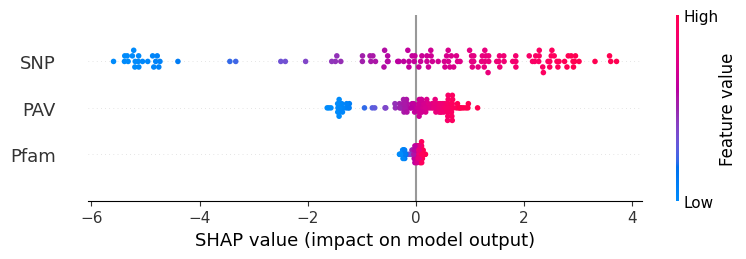

In [200]:
shap.summary_plot(shap_values_meta, meta_features_test, feature_names=["SNP", "PAV", "Pfam"], show=False)
plt.savefig(
    "stack_model_lasso_so_withenv.png",
    dpi=600,
    bbox_inches="tight"
)

# Variance threshold models

## Load datasets

In [50]:
snp = pd.read_pickle("lasso_SNP_training_data.pkl")
snp.head()

,Gm01_782148,Gm01_1381480,Gm01_2611788,Gm01_4432828,Gm01_7137165,Gm01_7544276,Gm01_8931835,Gm01_34025243,Gm01_46985479,Gm01_47028050,...,SOYBEAN.EVALUATION.MS2000_02,SOYBEAN.EVALUATION.MS2001_02,SOYBEAN.EVALUATION.MS2001_03,SOYBEAN.EVALUATION.MS923,SOYBEAN.EVALUATION.MS945,SOYBEAN.EVALUATION.MS967,SOYBEAN.EVALUATION.MS989,SOYBEAN.GENERAL,WILD.SOYBEAN.EVAL.1IL85,seed_oil
new_line,,,,,,,,,,,,,,,,,,,,,
AB-01_SOYBEAN.EVALUATION.4IL87,0,0,0,0,0,0,0,2,0,0,...,0,0,0,0,0,0,0,0,0,17.6
AB-02_SOYBEAN.EVALUATION.MS2001_02,2,0,0,0,2,2,2,0,0,0,...,0,1,0,0,0,0,0,0,0,16.8
BR-24_SOYBEAN.CHEMICAL.NB.2009,0,2,0,0,0,0,0,2,2,2,...,0,0,0,0,0,0,0,0,0,20.6
ESS_SOYBEAN.CHEMICAL.NB.2009,0,2,0,0,0,0,0,2,2,2,...,0,0,0,0,0,0,0,0,0,20.9
ESS_SOYBEAN.EVALUATION.5IL90,0,2,0,0,0,0,0,2,2,2,...,0,0,0,0,0,0,0,0,0,19.6


In [51]:
snp['Data-storage-ID'] = snp.index.to_series().str.split('_').str[0]
#fs_data['Line'] = fs_data.index.str.split('_').str[0]
snp = snp.reset_index(drop=True).set_index('Data-storage-ID')
snp.head()

,Gm01_782148,Gm01_1381480,Gm01_2611788,Gm01_4432828,Gm01_7137165,Gm01_7544276,Gm01_8931835,Gm01_34025243,Gm01_46985479,Gm01_47028050,...,SOYBEAN.EVALUATION.MS2000_02,SOYBEAN.EVALUATION.MS2001_02,SOYBEAN.EVALUATION.MS2001_03,SOYBEAN.EVALUATION.MS923,SOYBEAN.EVALUATION.MS945,SOYBEAN.EVALUATION.MS967,SOYBEAN.EVALUATION.MS989,SOYBEAN.GENERAL,WILD.SOYBEAN.EVAL.1IL85,seed_oil
Data-storage-ID,,,,,,,,,,,,,,,,,,,,,
AB-01,0,0,0,0,0,0,0,2,0,0,...,0,0,0,0,0,0,0,0,0,17.6
AB-02,2,0,0,0,2,2,2,0,0,0,...,0,1,0,0,0,0,0,0,0,16.8
BR-24,0,2,0,0,0,0,0,2,2,2,...,0,0,0,0,0,0,0,0,0,20.6
ESS,0,2,0,0,0,0,0,2,2,2,...,0,0,0,0,0,0,0,0,0,20.9
ESS,0,2,0,0,0,0,0,2,2,2,...,0,0,0,0,0,0,0,0,0,19.6


In [52]:
snp1 = snp.iloc[:, 0:277]
snp1.head()

,Gm01_782148,Gm01_1381480,Gm01_2611788,Gm01_4432828,Gm01_7137165,Gm01_7544276,Gm01_8931835,Gm01_34025243,Gm01_46985479,Gm01_47028050,...,SOYBEAN.EVALUATION.MS1999_01,SOYBEAN.EVALUATION.MS2000_02,SOYBEAN.EVALUATION.MS2001_02,SOYBEAN.EVALUATION.MS2001_03,SOYBEAN.EVALUATION.MS923,SOYBEAN.EVALUATION.MS945,SOYBEAN.EVALUATION.MS967,SOYBEAN.EVALUATION.MS989,SOYBEAN.GENERAL,WILD.SOYBEAN.EVAL.1IL85
Data-storage-ID,,,,,,,,,,,,,,,,,,,,,
AB-01,0,0,0,0,0,0,0,2,0,0,...,0,0,0,0,0,0,0,0,0,0
AB-02,2,0,0,0,2,2,2,0,0,0,...,0,0,1,0,0,0,0,0,0,0
BR-24,0,2,0,0,0,0,0,2,2,2,...,0,0,0,0,0,0,0,0,0,0
ESS,0,2,0,0,0,0,0,2,2,2,...,0,0,0,0,0,0,0,0,0,0
ESS,0,2,0,0,0,0,0,2,2,2,...,0,0,0,0,0,0,0,0,0,0


In [53]:
y1 = snp["seed_oil"]
y1.head()

Data-storage-ID
AB-01    17.6
AB-02    16.8
BR-24    20.6
ESS      20.9
ESS      19.6
Name: seed_oil, dtype: float64

In [54]:
y_final = snp["seed_oil"]
y_final.head()

Data-storage-ID
AB-01    17.6
AB-02    16.8
BR-24    20.6
ESS      20.9
ESS      19.6
Name: seed_oil, dtype: float64

In [55]:
pav = pd.read_pickle("gene_pav_afterFS_varthreshold_training_data.pkl")
pav.head()

,GlymaLee.01G000100.1.v1.1,GlymaLee.01G030900.1.v1.1,GlymaLee.01G034000.1.v1.1,GlymaLee.01G044800.1.v1.1,GlymaLee.01G044900.1.v1.1,GlymaLee.01G072000.1.v1.1,GlymaLee.01G073900.1.v1.1,GlymaLee.01G074000.1.v1.1,GlymaLee.01G076200.1.v1.1,GlymaLee.01G085600.1.v1.1,...,SOYBEAN.EVALUATION.MS2000_02,SOYBEAN.EVALUATION.MS2001_02,SOYBEAN.EVALUATION.MS2001_03,SOYBEAN.EVALUATION.MS923,SOYBEAN.EVALUATION.MS945,SOYBEAN.EVALUATION.MS967,SOYBEAN.EVALUATION.MS989,SOYBEAN.GENERAL,WILD.SOYBEAN.EVAL.1IL85,seed_oil
new_line,,,,,,,,,,,,,,,,,,,,,
HN076_SOYBEAN.CHEMICAL.NB.2009,1,0,1,1,1,1,1,1,0,1,...,0,0,0,0,0,0,0,0,0,15.4
USB-378_SOYBEAN.EVALUATION.MS2001_02,1,0,1,1,1,1,1,1,1,0,...,0,1,0,0,0,0,0,0,0,15.3
SRR1533285_SOYBEAN.CHEMICAL.NB.2009,1,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,21.3
USB-470_SOYBEAN.EVALUATION.1IL66,1,0,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,19.2
SRR1533310_SOYBEAN.EVALUATION.2IL81.1,1,0,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,17.8


In [56]:
pav['Data-storage-ID'] = pav.index.to_series().str.split('_').str[0]
#fs_data['Line'] = fs_data.index.str.split('_').str[0]
pav = pav.reset_index(drop=True).set_index('Data-storage-ID')
pav.head()

,GlymaLee.01G000100.1.v1.1,GlymaLee.01G030900.1.v1.1,GlymaLee.01G034000.1.v1.1,GlymaLee.01G044800.1.v1.1,GlymaLee.01G044900.1.v1.1,GlymaLee.01G072000.1.v1.1,GlymaLee.01G073900.1.v1.1,GlymaLee.01G074000.1.v1.1,GlymaLee.01G076200.1.v1.1,GlymaLee.01G085600.1.v1.1,...,SOYBEAN.EVALUATION.MS2000_02,SOYBEAN.EVALUATION.MS2001_02,SOYBEAN.EVALUATION.MS2001_03,SOYBEAN.EVALUATION.MS923,SOYBEAN.EVALUATION.MS945,SOYBEAN.EVALUATION.MS967,SOYBEAN.EVALUATION.MS989,SOYBEAN.GENERAL,WILD.SOYBEAN.EVAL.1IL85,seed_oil
Data-storage-ID,,,,,,,,,,,,,,,,,,,,,
HN076,1,0,1,1,1,1,1,1,0,1,...,0,0,0,0,0,0,0,0,0,15.4
USB-378,1,0,1,1,1,1,1,1,1,0,...,0,1,0,0,0,0,0,0,0,15.3
SRR1533285,1,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,21.3
USB-470,1,0,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,19.2
SRR1533310,1,0,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,17.8


In [57]:
y2 = pav["seed_oil"]
y2.head()

Data-storage-ID
HN076         15.4
USB-378       15.3
SRR1533285    21.3
USB-470       19.2
SRR1533310    17.8
Name: seed_oil, dtype: float64

In [58]:
pav1 = pav.iloc[:, 0:2951]
pav1.head()

,GlymaLee.01G000100.1.v1.1,GlymaLee.01G030900.1.v1.1,GlymaLee.01G034000.1.v1.1,GlymaLee.01G044800.1.v1.1,GlymaLee.01G044900.1.v1.1,GlymaLee.01G072000.1.v1.1,GlymaLee.01G073900.1.v1.1,GlymaLee.01G074000.1.v1.1,GlymaLee.01G076200.1.v1.1,GlymaLee.01G085600.1.v1.1,...,SOYBEAN.EVALUATION.MS1999_01,SOYBEAN.EVALUATION.MS2000_02,SOYBEAN.EVALUATION.MS2001_02,SOYBEAN.EVALUATION.MS2001_03,SOYBEAN.EVALUATION.MS923,SOYBEAN.EVALUATION.MS945,SOYBEAN.EVALUATION.MS967,SOYBEAN.EVALUATION.MS989,SOYBEAN.GENERAL,WILD.SOYBEAN.EVAL.1IL85
Data-storage-ID,,,,,,,,,,,,,,,,,,,,,
HN076,1,0,1,1,1,1,1,1,0,1,...,0,0,0,0,0,0,0,0,0,0
USB-378,1,0,1,1,1,1,1,1,1,0,...,0,0,1,0,0,0,0,0,0,0
SRR1533285,1,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
USB-470,1,0,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
SRR1533310,1,0,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0


In [59]:
pfam = pd.read_pickle("pfam_pav_newIDs_eval5_varthreshold_training_data.pkl")
pfam.head()

,PF00931_01G030900,PF20160_01G030900,PF00332_01G044800,PF00195_01G074000,PF02797_01G074000,PF13041_01G086700,PF05056_01G086800,PF00931_01G088400,PF01582_01G088400,PF01086_01G090700,...,SOYBEAN.EVALUATION.MS2000_02,SOYBEAN.EVALUATION.MS2001_02,SOYBEAN.EVALUATION.MS2001_03,SOYBEAN.EVALUATION.MS923,SOYBEAN.EVALUATION.MS945,SOYBEAN.EVALUATION.MS967,SOYBEAN.EVALUATION.MS989,SOYBEAN.GENERAL,WILD.SOYBEAN.EVAL.1IL85,seed_oil
new_line,,,,,,,,,,,,,,,,,,,,,
HN076_SOYBEAN.CHEMICAL.NB.2009,0,0,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,15.4
USB-378_SOYBEAN.EVALUATION.MS2001_02,0,0,1,1,1,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,15.3
SRR1533285_SOYBEAN.CHEMICAL.NB.2009,1,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,21.3
USB-470_SOYBEAN.EVALUATION.1IL66,0,0,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,19.2
SRR1533310_SOYBEAN.EVALUATION.2IL81.1,0,0,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,17.8


In [60]:
pfam['Data-storage-ID'] = pfam.index.to_series().str.split('_').str[0]
#fs_data['Line'] = fs_data.index.str.split('_').str[0]
pfam = pfam.reset_index(drop=True).set_index('Data-storage-ID')
pfam.head()

,PF00931_01G030900,PF20160_01G030900,PF00332_01G044800,PF00195_01G074000,PF02797_01G074000,PF13041_01G086700,PF05056_01G086800,PF00931_01G088400,PF01582_01G088400,PF01086_01G090700,...,SOYBEAN.EVALUATION.MS2000_02,SOYBEAN.EVALUATION.MS2001_02,SOYBEAN.EVALUATION.MS2001_03,SOYBEAN.EVALUATION.MS923,SOYBEAN.EVALUATION.MS945,SOYBEAN.EVALUATION.MS967,SOYBEAN.EVALUATION.MS989,SOYBEAN.GENERAL,WILD.SOYBEAN.EVAL.1IL85,seed_oil
Data-storage-ID,,,,,,,,,,,,,,,,,,,,,
HN076,0,0,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,15.4
USB-378,0,0,1,1,1,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,15.3
SRR1533285,1,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,21.3
USB-470,0,0,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,19.2
SRR1533310,0,0,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,17.8


In [61]:
pfam1 = pfam.iloc[:, 0:1229]
pfam1.head()

,PF00931_01G030900,PF20160_01G030900,PF00332_01G044800,PF00195_01G074000,PF02797_01G074000,PF13041_01G086700,PF05056_01G086800,PF00931_01G088400,PF01582_01G088400,PF01086_01G090700,...,SOYBEAN.EVALUATION.MS1999_01,SOYBEAN.EVALUATION.MS2000_02,SOYBEAN.EVALUATION.MS2001_02,SOYBEAN.EVALUATION.MS2001_03,SOYBEAN.EVALUATION.MS923,SOYBEAN.EVALUATION.MS945,SOYBEAN.EVALUATION.MS967,SOYBEAN.EVALUATION.MS989,SOYBEAN.GENERAL,WILD.SOYBEAN.EVAL.1IL85
Data-storage-ID,,,,,,,,,,,,,,,,,,,,,
HN076,0,0,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
USB-378,0,0,1,1,1,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0
SRR1533285,1,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
USB-470,0,0,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
SRR1533310,0,0,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0


In [62]:
y3 = pfam["seed_oil"]
y3.head()

Data-storage-ID
HN076         15.4
USB-378       15.3
SRR1533285    21.3
USB-470       19.2
SRR1533310    17.8
Name: seed_oil, dtype: float64

## Hyperparameter tuning of base models

### Base model for snps

In [63]:
X_all = snp1.values
y_all = y1.values

In [64]:
X_train, X_test, y_train, y_test = train_test_split(X_all, y_all, test_size=0.1, random_state=42)

In [65]:
snp_xgbreg = bayesian_xgb_search(X_train, y_train, space)

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Best XGB Parameters: OrderedDict([('colsample_bylevel', 0.5256968307605722), ('colsample_bytree', 0.5144416785303635), ('gamma', 0.49999999999999994), ('learning_rate', 0.516926824766437), ('max_delta_step', 5), ('max_depth', 0), ('min_child_weight', 9), ('n_estimators', 184), ('reg_alpha', 1.5123500696087276e-07), ('reg_lambda', 1000.0), ('subsample', 1.0)])


### Base models for pav

In [69]:
X_all = pav1.values
y_all = y2.values

In [70]:
X_train, X_test, y_train, y_test = train_test_split(X_all, y_all, test_size=0.1, random_state=42)

In [71]:
pav_xgbreg = bayesian_xgb_search(X_train, y_train, space)

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Best XGB Parameters: OrderedDict([('colsample_bylevel', 0.6093561197609833), ('colsample_bytree', 0.8584066342158617), ('gamma', 2.260579253768497e-05), ('learning_rate', 0.01690316271516304), ('max_delta_step', 10), ('max_depth', 22), ('min_child_weight', 2), ('n_estimators', 193), ('reg_alpha', 8.80522322948005e-09), ('reg_lambda', 1.197248667442437e-05), ('subsample', 0.25978022854064087)])


### Base models for pfam

In [72]:
X_all = pfam1.values
y_all = y3.values

In [73]:
X_train, X_test, y_train, y_test = train_test_split(X_all, y_all, test_size=0.1, random_state=42)

In [74]:
pfam_xgbreg = bayesian_xgb_search(X_train, y_train, space)

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Best XGB Parameters: OrderedDict([('colsample_bylevel', 0.4160029192647807), ('colsample_bytree', 0.7304484857455519), ('gamma', 0.13031389926541354), ('learning_rate', 0.042815319280763466), ('max_delta_step', 13), ('max_depth', 21), ('min_child_weight', 4), ('n_estimators', 161), ('reg_alpha', 5.497557739289786e-07), ('reg_lambda', 0.05936070635912049), ('subsample', 0.5544643023916863)])


## Stacking

In [75]:
base_models = [
    snp_xgbreg,
    pav_xgbreg,
    pfam_xgbreg
]
meta_model = Ridge(alpha=1.0, random_state=42, max_iter=10000)

In [76]:
X1 = snp1.to_numpy()
X2 = pav1.to_numpy()
X3 = pfam1.to_numpy()

In [77]:
stack_model = MultiInputStackingRegressor(
    base_models=base_models,
    meta_model=meta_model,
    n_folds=5
)

In [78]:
stack_model.fit([X1, X2, X3], y_final)

/tmp/ipykernel_3922268/3372023707.py:38: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  model_clone.fit(X_train, y[train_idx])


MultiInputStackingRegressor(base_models=[XGBRegressor(base_score=None,
                                                      booster=None,
                                                      callbacks=None,
                                                      colsample_bylevel=0.5256968307605722,
                                                      colsample_bynode=None,
                                                      colsample_bytree=0.5144416785303635,
                                                      device=None,
                                                      early_stopping_rounds=None,
                                                      enable_categorical=False,
                                                      eval_metric=None,
                                                      feature_types=None,
                                                      feature_weights=None,
                                                      gamma=0.49999999999999994,
                                                      grow_polic...
                                                      interaction_constraints=None,
                                                      learning_rate=0.042815319280763466,
                                                      max_bin=None,
                                                      max_cat_threshold=None,
                                                      max_cat_to_onehot=None,
                                                      max_delta_step=13,
                                                      max_depth=21,
                                                      max_leaves=None,
                                                      min_child_weight=4,
                                                      missing=nan,
                                                      monotone_constraints=None,
                                                      multi_strategy=None,
                                                      n_estimators=161,
                                                      n_jobs=None,
                                                      num_parallel_tree=None, ...)],
                            meta_model=Ridge(max_iter=10000, random_state=42),
                            n_folds=5)

In [79]:
meta_df = pd.DataFrame(
    stack_model.meta_features_,
    columns=["SNP_pred", "PAV_pred", "Pfam_pred"]
)
meta_df.to_pickle("meta_features_VT_so.pkl")
meta_df.head()

,SNP_pred,PAV_pred,Pfam_pred
0,15.452444,18.268253,18.734303
1,15.423999,17.142513,16.939087
2,19.923702,17.422926,17.733213
3,20.478226,16.997025,15.790768
4,20.389118,17.506968,17.720854


In [80]:
meta_df.describe()

,SNP_pred,PAV_pred,Pfam_pred
count,1144.000000,1144.000000,1144.000000
mean,17.375109,17.252582,17.308527
std,3.199734,1.262365,1.891439
min,9.672393,11.918230,8.464426
25%,15.949156,16.602377,16.466240
50%,18.321103,17.362637,17.446734
75%,19.810788,18.020907,18.360859
max,22.174915,20.889000,22.598087


In [81]:
meta_df.corr()

,SNP_pred,PAV_pred,Pfam_pred
SNP_pred,1.000000,-0.016529,-0.001064
PAV_pred,-0.016529,1.000000,0.817898
Pfam_pred,-0.001064,0.817898,1.000000


In [82]:
corr_matrix = meta_df.corr()

p_matrix = pd.DataFrame(index=meta_df.columns, columns=meta_df.columns)

for col1 in meta_df.columns:
    for col2 in meta_df.columns:
        r, p = pearsonr(meta_df[col1], meta_df[col2])
        p_matrix.loc[col1, col2] = p

print("Correlation matrix:")
print(corr_matrix)

print("\nP-value matrix:")
print(p_matrix)

Correlation matrix:
           SNP_pred  PAV_pred  Pfam_pred
SNP_pred   1.000000 -0.016529  -0.001064
PAV_pred  -0.016529  1.000000   0.817898
Pfam_pred -0.001064  0.817898   1.000000

P-value matrix:
           SNP_pred  PAV_pred Pfam_pred
SNP_pred        0.0  0.576508  0.971319
PAV_pred   0.576508       0.0       0.0
Pfam_pred  0.971319       0.0       0.0


In [101]:
meta_search = BayesSearchCV(
    estimator=Ridge(),
    search_spaces=rr_space,
    n_iter=10,  # usually enough for 1D
    cv=5,
    scoring=None,
    random_state=42,
    n_jobs=-1
)

meta_search.fit(stack_model.meta_features_, y_final)

,estimator,Ridge()
,search_spaces,{'alpha': Real(low=1e-0...m='normalize')}
,optimizer_kwargs,None
,n_iter,10
,scoring,None
,fit_params,None
,n_jobs,-1
,n_points,1
,iid,'deprecated'
,refit,True
,cv,5


In [102]:
stack_model.meta_model = meta_search.best_estimator_

## Testing

In [103]:
holdout = pd.read_pickle("snp_pav_pfam_holdout_varthreshold.pkl")

In [104]:
holdout.head()

,Gm01_3567,Gm01_3677,Gm01_7345,Gm01_7357,Gm01_8865,Gm01_8876,Gm01_10496,Gm01_11433,Gm01_13491,Gm01_15043,...,SOYBEAN.EVALUATION.MS2000_02,SOYBEAN.EVALUATION.MS2001_02,SOYBEAN.EVALUATION.MS2001_03,SOYBEAN.EVALUATION.MS923,SOYBEAN.EVALUATION.MS945,SOYBEAN.EVALUATION.MS967,SOYBEAN.EVALUATION.MS989,SOYBEAN.GENERAL,WILD.SOYBEAN.EVAL.1IL85,seed_oil
new_line,,,,,,,,,,,,,,,,,,,,,
HN009_SOYBEAN.EVALUATION.5IL90,0,0,1,0,0,1,1,0,0,0,...,0,0,0,0,0,0,0,0,0,16.8
HN010_SOYBEAN.EVALUATION.4IL87,0,0,0,1,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,18.3
HN015_SOYBEAN.EVALUATION.3IL83.2,0,0,0,1,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,15.0
HN017B_SOYBEAN.EVALUATION.3IL83.2,0,0,0,1,0,0,0,1,1,0,...,0,0,0,0,0,0,0,0,0,15.5
HN023_SOYBEAN.EVALUATION.2IL81.2,0,0,0,1,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,15.6


In [105]:
snp_holdout = holdout[snp1.columns]

In [106]:
snp_holdout['Data-storage-ID'] = snp_holdout.index.to_series().str.split('_').str[0]
#fs_data['Line'] = fs_data.index.str.split('_').str[0]
snp_holdout = snp_holdout.reset_index(drop=True).set_index('Data-storage-ID')
snp_holdout.head()

/tmp/ipykernel_3322190/3552470459.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  snp_holdout['Data-storage-ID'] = snp_holdout.index.to_series().str.split('_').str[0]


,Gm01_782148,Gm01_1381480,Gm01_2611788,Gm01_4432828,Gm01_7137165,Gm01_7544276,Gm01_8931835,Gm01_34025243,Gm01_46985479,Gm01_47028050,...,SOYBEAN.EVALUATION.MS1999_01,SOYBEAN.EVALUATION.MS2000_02,SOYBEAN.EVALUATION.MS2001_02,SOYBEAN.EVALUATION.MS2001_03,SOYBEAN.EVALUATION.MS923,SOYBEAN.EVALUATION.MS945,SOYBEAN.EVALUATION.MS967,SOYBEAN.EVALUATION.MS989,SOYBEAN.GENERAL,WILD.SOYBEAN.EVAL.1IL85
Data-storage-ID,,,,,,,,,,,,,,,,,,,,,
HN009,0,0,0,0,1,0,0,0,2,2,...,0,0,0,0,0,0,0,0,0,0
HN010,0,0,0,2,2,2,2,0,2,2,...,0,0,0,0,0,0,0,0,0,0
HN015,2,0,0,0,2,2,2,0,2,2,...,0,0,0,0,0,0,0,0,0,0
HN017B,0,0,0,2,2,2,2,0,2,2,...,0,0,0,0,0,0,0,0,0,0
HN023,2,0,0,0,2,0,2,0,2,2,...,0,0,0,0,0,0,0,0,0,0


In [107]:
pav_holdout = holdout[pav1.columns]

In [108]:
pav_holdout['Data-storage-ID'] = pav_holdout.index.to_series().str.split('_').str[0]
#fs_data['Line'] = fs_data.index.str.split('_').str[0]
pav_holdout = pav_holdout.reset_index(drop=True).set_index('Data-storage-ID')
pav_holdout.head()

/tmp/ipykernel_3322190/2899270742.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  pav_holdout['Data-storage-ID'] = pav_holdout.index.to_series().str.split('_').str[0]


,GlymaLee.01G000100.1.v1.1,GlymaLee.01G030900.1.v1.1,GlymaLee.01G034000.1.v1.1,GlymaLee.01G044800.1.v1.1,GlymaLee.01G044900.1.v1.1,GlymaLee.01G072000.1.v1.1,GlymaLee.01G073900.1.v1.1,GlymaLee.01G074000.1.v1.1,GlymaLee.01G076200.1.v1.1,GlymaLee.01G085600.1.v1.1,...,SOYBEAN.EVALUATION.MS1999_01,SOYBEAN.EVALUATION.MS2000_02,SOYBEAN.EVALUATION.MS2001_02,SOYBEAN.EVALUATION.MS2001_03,SOYBEAN.EVALUATION.MS923,SOYBEAN.EVALUATION.MS945,SOYBEAN.EVALUATION.MS967,SOYBEAN.EVALUATION.MS989,SOYBEAN.GENERAL,WILD.SOYBEAN.EVAL.1IL85
Data-storage-ID,,,,,,,,,,,,,,,,,,,,,
HN009,1,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
HN010,1,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
HN015,1,0,1,1,1,1,1,1,0,1,...,0,0,0,0,0,0,0,0,0,0
HN017B,1,0,1,1,1,1,1,1,0,1,...,0,0,0,0,0,0,0,0,0,0
HN023,1,0,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0


In [109]:
pfam_holdout = holdout[pfam1.columns]

In [110]:
pfam_holdout['Data-storage-ID'] = pfam_holdout.index.to_series().str.split('_').str[0]
#fs_data['Line'] = fs_data.index.str.split('_').str[0]
pfam_holdout = pfam_holdout.reset_index(drop=True).set_index('Data-storage-ID')
pfam_holdout.head()

/tmp/ipykernel_3322190/577540637.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  pfam_holdout['Data-storage-ID'] = pfam_holdout.index.to_series().str.split('_').str[0]


,PF00931_01G030900,PF20160_01G030900,PF00332_01G044800,PF00195_01G074000,PF02797_01G074000,PF13041_01G086700,PF05056_01G086800,PF00931_01G088400,PF01582_01G088400,PF01086_01G090700,...,SOYBEAN.EVALUATION.MS1999_01,SOYBEAN.EVALUATION.MS2000_02,SOYBEAN.EVALUATION.MS2001_02,SOYBEAN.EVALUATION.MS2001_03,SOYBEAN.EVALUATION.MS923,SOYBEAN.EVALUATION.MS945,SOYBEAN.EVALUATION.MS967,SOYBEAN.EVALUATION.MS989,SOYBEAN.GENERAL,WILD.SOYBEAN.EVAL.1IL85
Data-storage-ID,,,,,,,,,,,,,,,,,,,,,
HN009,1,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
HN010,1,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
HN015,0,0,1,1,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
HN017B,0,0,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
HN023,0,0,1,1,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [111]:
cov_holdout = holdout[cov.columns]

In [112]:
cov_holdout['Data-storage-ID'] = cov_holdout.index.to_series().str.split('_').str[0]
#fs_data['Line'] = fs_data.index.str.split('_').str[0]
cov_holdout = cov_holdout.reset_index(drop=True).set_index('Data-storage-ID')
cov_holdout.head()

/tmp/ipykernel_3322190/403245011.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cov_holdout['Data-storage-ID'] = cov_holdout.index.to_series().str.split('_').str[0]


,SOJA.EVALUATION.IL989,SOJA.EVALUATION.MS989,SOYBEAN.CHEMICAL.NB.2009,SOYBEAN.EVALUATION.1IL64,SOYBEAN.EVALUATION.1IL66,SOYBEAN.EVALUATION.1MN63,SOYBEAN.EVALUATION.2IL81.1,SOYBEAN.EVALUATION.2IL81.2,SOYBEAN.EVALUATION.2KY81,SOYBEAN.EVALUATION.2MN81,...,SOYBEAN.EVALUATION.MS1999_01,SOYBEAN.EVALUATION.MS2000_02,SOYBEAN.EVALUATION.MS2001_02,SOYBEAN.EVALUATION.MS2001_03,SOYBEAN.EVALUATION.MS923,SOYBEAN.EVALUATION.MS945,SOYBEAN.EVALUATION.MS967,SOYBEAN.EVALUATION.MS989,SOYBEAN.GENERAL,WILD.SOYBEAN.EVAL.1IL85
Data-storage-ID,,,,,,,,,,,,,,,,,,,,,
HN009,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
HN010,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
HN015,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
HN017B,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
HN023,0,0,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0


In [113]:
y_final_test = holdout['seed_oil'].values

In [114]:
X1_test = snp_holdout.values
X2_test = pav_holdout.values
X3_test = pfam_holdout.values
X4_test = cov_holdout.values

In [115]:
y_pred = stack_model.predict([X1_test, X2_test, X3_test])

In [116]:
r2 = r2_score(y_final_test, y_pred)
print(f"R²: {r2:.4f}")

R²: 0.8655


In [117]:
mse = mean_squared_error(y_final_test, y_pred)
print(f"MSE: {mse:.4f}")

MSE: 1.8222


In [118]:
rmse = sqrt(mean_squared_error(y_final_test, y_pred))
print(f"RMSE: {rmse:.4f}")

RMSE: 1.3499


In [119]:
r = np.corrcoef(y_final_test, y_pred)[0, 1]
print(f"Pearson r: {r:.4f}")

Pearson r: 0.9303


In [120]:
with open("stack_model_varthreshold_so_withenv.pkl", "wb") as f:
    pickle.dump(stack_model, f)

In [ ]:
with open("stack_model.pkl", "rb") as f:
    stack_model = pickle.load(f)

In [173]:
X_test_list = [X1_test, X2_test, X3_test]  # same order as training

meta_features_test = np.column_stack([
    np.mean([model.predict(X_test_list[i]) for model in stack_model.base_models_[i]], axis=0)
    for i in range(len(stack_model.base_models_))
])

In [174]:
meta_model = stack_model.meta_model

In [175]:
explainer_meta = shap.LinearExplainer(meta_model, meta_features_test)

In [176]:
shap_values_meta = explainer_meta.shap_values(meta_features_test)

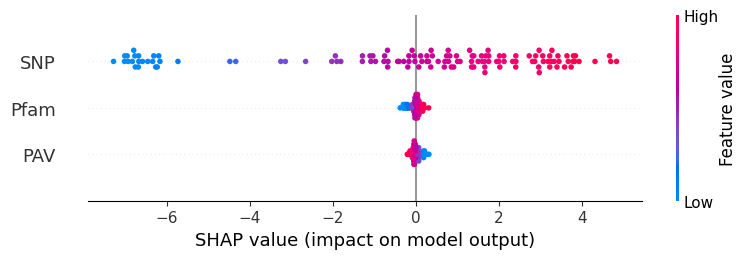

In [177]:
shap.summary_plot(shap_values_meta, meta_features_test, feature_names=["SNP", "PAV", "Pfam"], show=False)
plt.savefig(
    "stack_model_varthreshold_so_withenv.png",
    dpi=600,
    bbox_inches="tight"
)